In [226]:
import os
import warnings

import agama
import astropy
import cmasher as cmr
import gc_utils
import gizmo_analysis as gizmo
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import utilities as ut
from matplotlib.animation import PillowWriter
from matplotlib.colors import LogNorm, Normalize
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy import stats
from scipy.interpolate import griddata, interp1d
from scipy.ndimage import gaussian_filter
from scipy.optimize import curve_fit, minimize
from scipy.signal import find_peaks
from scipy.stats import binned_statistic_2d, gaussian_kde
from sklearn.svm import SVC


In [227]:
sim = "m12m"
sim_dir = "/Users/z5114326/Documents/simulations/"

ghost_file = f"{sim_dir}{sim}/{sim}_ghosts.hdf5"
ghost_data = h5py.File(ghost_file, "r")

snap = 600

In [228]:
in_situ_msk = True  # True for include in_situ
ex_situ_msk = False  # True for include ex_situ

In [229]:
public_snapshot_file = sim_dir + "snapshot_times_public.txt"
pub_data = pd.read_table(public_snapshot_file, comment="#", header=None, sep=r"\s+")
pub_data.columns = [
    "index",
    "scale_factor",
    "redshift",
    "time_Gyr",
    "lookback_time_Gyr",
    "time_width_Myr",
]
time = float(pub_data[pub_data["index"] == snap]["time_Gyr"].values[0])

In [230]:
def lower_envelope(x, m, x_b, y_b):
    return np.where(x < x_b, m * (x - x_b) + y_b, y_b)


def kde_threshold(Z, fraction):
    """Return KDE level that encloses fraction of total probability."""
    sorted_Z = np.sort(Z.ravel())[::-1]  # descending
    cumsum = np.cumsum(sorted_Z)
    cumsum /= cumsum[-1]  # normalize
    # Find the smallest Z value where cumulative sum >= fraction
    level = sorted_Z[np.searchsorted(cumsum, fraction)]
    return level


def plot_bounding(xlog, ylog, fraction=0.98):
    xy = np.vstack([xlog, ylog])
    kde = gaussian_kde(xy)
    xmin, xmax = xlog.min(), xlog.max()
    ymin, ymax = ylog.min(), ylog.max()

    X, Y = np.meshgrid(np.linspace(xmin, xmax, 200), np.linspace(ymin, ymax, 200))
    Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)

    level = kde_threshold(Z, fraction)
    cont = plt.contour(X, Y, Z, levels=[level], colors="orange")
    plt.close()

    contour_path = cont.collections[0].get_paths()[0]
    vertices = contour_path.vertices
    x_contour, y_contour = vertices[:, 0], vertices[:, 1]

    # --- Keep only the "lower" part of the contour ---
    # We'll bin x values and take the minimum y in each bin
    bins = np.linspace(x_contour.min(), x_contour.max(), 100)
    x_bin_centers = 0.5 * (bins[:-1] + bins[1:])
    y_lower = []
    x_lower = []

    for i in range(len(bins) - 1):
        mask = (x_contour >= bins[i]) & (x_contour < bins[i + 1])
        if np.any(mask):
            x_lower.append(x_bin_centers[i])
            y_lower.append(np.min(y_contour[mask]))

    x_lower = np.array(x_lower)
    y_lower = np.array(y_lower)

    # --- Fit lower-envelope function ---
    p0 = [-1, np.median(x_lower), np.median(y_lower)]  # initial guess: slope, x_b, y_b
    params, cov = curve_fit(lower_envelope, x_lower, y_lower, p0=p0)

    xfit = np.logspace(1, 7)
    xfitlog = np.log10(xfit)
    yfitlog = lower_envelope(xfitlog, *params)
    yfit = 10**yfitlog

    plot_dict = {"xfit": xfit, "yfit": yfit, "params": params, "cov": cov}

    return plot_dict

In [231]:
it_dict = {}
for it_id in ghost_data.keys():
    src_dat = ghost_data[it_id]["source"]

    amsk = src_dat["grpid"][()] == 0

    if (in_situ_msk) & (not ex_situ_msk):
        msk = amsk
    elif (not in_situ_msk) & (ex_situ_msk):
        msk = ~amsk
    else:
        msk = np.ones(len(amsk), dtype=bool)

    m_tfo = 10 ** src_dat["logm_tfor"][msk]
    m_tfo_ev = 0.55 * (10 ** src_dat["logm_tfor"][msk])

    m_tz0_log = src_dat["logm_tz0"][msk]
    m_tz0 = np.array([10**x if x != -1 else 0 for x in m_tz0_log])

    tfor = src_dat["tfor"][msk]
    tdis = src_dat["tdis"][msk]

    age = time - tfor
    age_p = np.array([x - y if x != -1 else time - y for x, y in zip(tdis, tfor)])

    t_tz0 = src_dat["torb_600"][msk]
    s_tz0 = np.array(src_dat["s_flag"][msk], dtype=bool)

    ml = m_tfo_ev - m_tz0
    ml_rate = (m_tfo_ev - m_tz0) / age_p

    it_dict[it_id] = {}
    it_dict[it_id]["m_tfo"] = m_tfo
    it_dict[it_id]["m_tfo_ev"] = m_tfo_ev
    it_dict[it_id]["m_tz0"] = m_tz0
    it_dict[it_id]["tfor"] = tfor
    it_dict[it_id]["tdis"] = tdis
    it_dict[it_id]["age"] = age
    it_dict[it_id]["age_p"] = age_p
    it_dict[it_id]["t_tz0"] = t_tz0
    it_dict[it_id]["s_tz0"] = s_tz0
    it_dict[it_id]["ml"] = ml
    it_dict[it_id]["ml_rate"] = ml_rate

In [232]:
x = np.array([])
y = np.array([])
c = np.array([])

for it_id in it_dict.keys():
    msk_i = it_dict[it_id]["s_tz0"]

    x_i = it_dict[it_id]["m_tz0"][msk_i]
    y_i = it_dict[it_id]["t_tz0"][msk_i]
    c_i = it_dict[it_id]["m_tfo"][msk_i]

    x = np.concatenate((x, x_i))
    y = np.concatenate((y, y_i))
    c = np.concatenate((c, c_i))

xlog = np.log10(x)
ylog = np.log10(y)
clog = np.log10(c)

xlog_ylog = np.vstack([xlog, ylog])
kde = gaussian_kde(xlog_ylog)
z = kde(xlog_ylog)

threshold = np.percentile(z, 2)  # 5th percentile corresponds to outside 95%

xlog_msk = xlog.copy()
ylog_msk = ylog.copy()
clog_msk = clog.copy()

xlog_msk[z < threshold] = np.nan
ylog_msk[z < threshold] = np.nan
clog_msk[z < threshold] = np.nan

plot_dict = plot_bounding(xlog, ylog, fraction=0.98)

xbound = plot_dict["xfit"]
ybound = plot_dict["yfit"]

xbound_log = np.log10(xbound)
ybound_log = np.log10(ybound)

# Create grid
xi = np.linspace(1, 7, 200)
yi = np.linspace(0.5, 4, 200)
Xi, Yi = np.meshgrid(xi, yi)

Zi_linear = griddata((xlog, ylog), clog, (Xi, Yi), method="linear")
Zi_nearest = griddata((xlog, ylog), clog, (Xi, Yi), method="nearest")
Zi = np.where(np.isnan(Zi_linear), Zi_nearest, Zi_linear)

Zi_smooth = gaussian_filter(Zi, sigma=2)  # Increase sigma for smoother lines

# Boundary mask
y_boundary = np.interp(Xi[0, :], xbound_log, ybound_log)
Y_boundary = np.tile(y_boundary, (Yi.shape[0], 1))
boundary_mask = Yi >= Y_boundary  # True where we keep values

# KDE threshold mask
# Interpolate z (density) onto the grid
Zi_kde = griddata((xlog, ylog), z, (Xi, Yi), method="nearest")  # nearest avoids NaNs
kde_mask = Zi_kde >= threshold  # True where density is above threshold

# Combine both masks
combined_mask = boundary_mask & kde_mask

# Apply mask to smoothed Zi
Zi_masked = np.where(combined_mask, Zi_smooth, np.nan)


/var/folders/nb/byfjq48d6jz8b3g74s3zr7rh0000gp/T/ipykernel_15169/2498956217.py:28: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  contour_path = cont.collections[0].get_paths()[0]


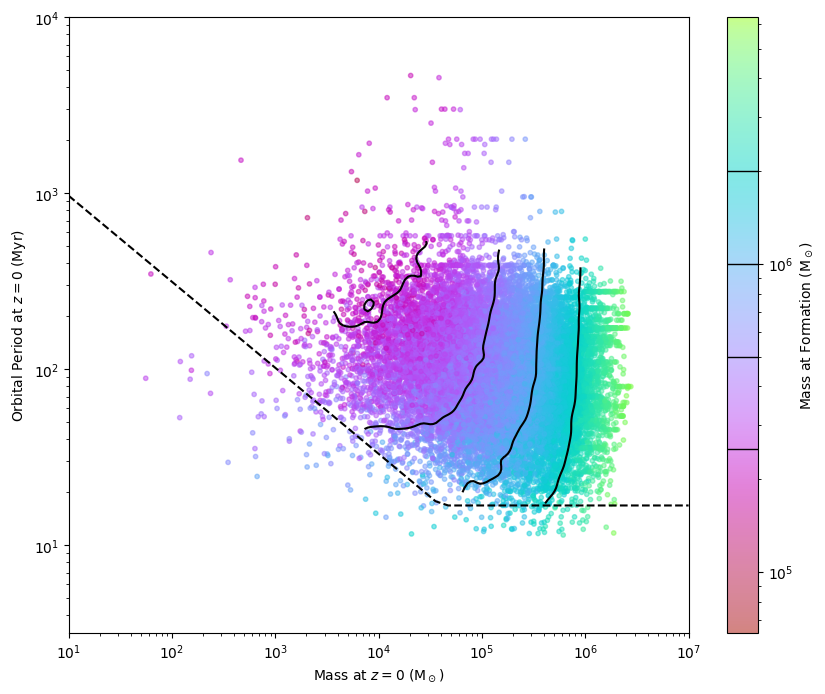

In [233]:
cmap = "cmr.neon"

plt.figure(figsize=(10, 8))

plt.scatter(x, y, c=c, s=10, alpha=0.5, norm=LogNorm(vmin=10**4.8, vmax=10**6.8), cmap=cmap)
cb = plt.colorbar()
cb.set_label(r"Mass at Formation (M$_\odot$)")

mass_levels = np.array([2.5, 5, 10, 20]) * 10**5
# mass_levels = 10 ** np.array([5.3, 5.50])
for level in mass_levels:
    cb.ax.axhline(level, color="k", lw=1.0, ls="-")  # Use axhline with actual data value

plt.plot(xbound, ybound, c="k", ls="--")

# mass_levels = 10 ** np.array([5.5, 6])
cs = plt.contour(10**Xi, 10**Yi, 10**Zi_masked, levels=mass_levels, colors="k", linewidths=1.5)
# plt.clabel(cs, inline=True, fmt="%.1e")

plt.xlabel(r"Mass at $z=0$ (M$_\odot$)")
plt.ylabel(r"Orbital Period at $z=0$ (Myr)")

plt.xscale("log")
plt.yscale("log")